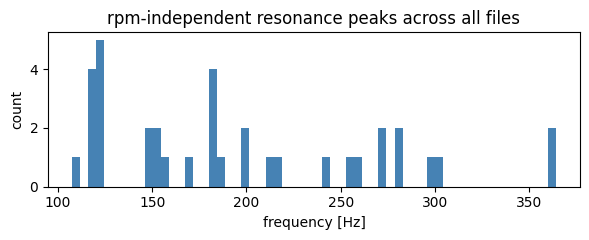

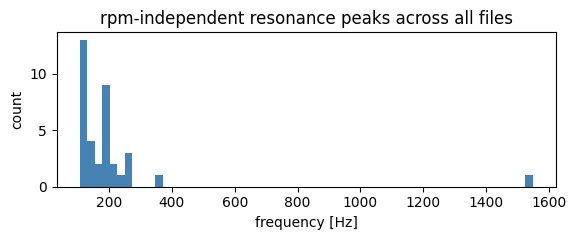

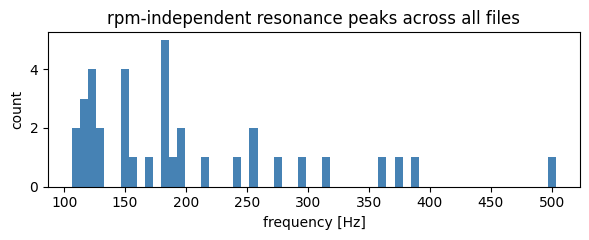

In [5]:
import glob, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from brf_lightning.data.bearing.utils import load_vibration_data
from brf_lightning.utils.kurtogram import spectral_kurtosis, max_sk_band
import glob, numpy as np, matplotlib.pyplot as plt, scipy.signal as sig

NPERSEG = 8192       # same as in your notebook

for BW in (1000, 2000, 4000):
    f_lo, f_hi = max_sk_band(f, sk, bandwidth=BW, min_freq=100, max_ratio=0.95)
    peak_hist = []
    for fp in Path("data/bearing_thl_v1").glob("*.csv"):
        df, fs = load_vibration_data(fp)
        x = df["sensor_bearing"].to_numpy(np.float32)

        # -------- 1) best resonance band from kurtogram -----------
        f, sk = spectral_kurtosis(x, fs, nperseg=NPERSEG)
        f_lo, f_hi = max_sk_band(f, sk, bandwidth=BW,
                                min_freq=100, max_ratio=0.95)

        # -------- 2) narrow-band filtering ------------------------
        sos = sig.butter(4, [f_lo*2/fs, f_hi*2/fs], btype="bandpass", output="sos")
        x_band = sig.sosfiltfilt(sos, x)

        # -------- 3) envelope spectrum ----------------------------
        env = np.abs(sig.hilbert(x_band))
        n_fft = 2**16                    # zero-padding for nicer peaks
        spec  = np.abs(np.fft.rfft(env, n=n_fft))
        freq  = np.fft.rfftfreq(n_fft, d=1/fs)

        # keep the 4 strongest lines >100 Hz (skip DC & rpm orders)
        top_idx = spec[(freq > 100)].argsort()[-4:]
        peak_hist.extend(freq[(freq > 100)][top_idx])

    # ------------ visualise histogram of detected resonances ---------------
    plt.figure(figsize=(6,2.5))
    plt.hist(peak_hist, bins=60, color="steelblue")
    plt.xlabel("frequency [Hz]"); plt.ylabel("count")
    plt.title("rpm-independent resonance peaks across all files")
    plt.tight_layout();  plt.show()

